### Visualize Tumor Microenvironment in PAAD cases

This notebook shows the TME composition in parental tumors from PAAD.
Setup user-defined parameters. Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub (parent) directory as `Code_dir`.

In [1]:
cohort = "PDAC"

Work_dir = "/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/groups/ac2248_gp/lz2841/ColumbiaProjects/HCMI-single-nuclei/" # path to GitHub folder

Additional parameters and cases in cohort are provided below.

In [2]:
cases=["HCM-CSHL-0073-C25", "HCM-CSHL-0078-C25", "HCM-CSHL-0089-C25", "HCM-BROD-0110-C25"]

reference = "cells_from_model" # reference used for the calculation of Protein Activity
filtering_level_vcf = "filtered_01" 
sample_assignment = "best_gt_thresh" 

# Postprocessing filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")

NN_vector = 15 # for Nearest Neighbors in UMAP visualization

Import packages and custom functions 

In [3]:
import sys
import scanpy as sc
import numpy as np 
from numpy import nanmedian, NaN
import pandas as pd
import os 
from matplotlib import rc_context
import seaborn as sns
import matplotlib.pyplot as plt
import pyviper
sc.settings.verbosity = 0
sc.logging.print_header()
sc.settings.set_figure_params(frameon=False, dpi=100, facecolor="white")
from matplotlib_venn import venn2, venn3
from sklearn.metrics import silhouette_samples
from matplotlib.backends.backend_pdf import PdfPages
import hdf5plugin
import argparse
import anndata
import gc
from contextlib import contextmanager
from prettytable import PrettyTable
from tabulate import tabulate
import warnings
warnings.simplefilter("ignore", category=UserWarning)
from scipy.sparse import issparse
import re
from matplotlib.colors import LinearSegmentedColormap
from itertools import compress
from scipy.stats import combine_pvalues
import scgen
import decoupler as dc
import phate
from openpyxl import Workbook
import math
sys.path.append(f'{Code_dir}funcs/')
from processing_funcs import *


# Custom function: retrieving putative malignant cells
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]
    

# Specify other graphic parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7


# Define the specific colors you want to use
T_M_colors = {
    "T": "#8dd3c7",  # Green for Tumor (T)
    "M": "#ffffb3",  # Yellow for Model (M)
}

2025-08-25 14:47:28.569480: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-25 14:47:28.580504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756147648.593061  648752 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756147648.596785  648752 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756147648.607081  648752 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.3 scipy==1.12.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13


Define palette for different cellular populations

In [4]:
## Plotting parameters
tab20 = plt.get_cmap("tab20")
PDAC_colormap = {
    'MOS': '#9E9AC9',   # Violet
    'ALS': '#3182BD',   # Blue
    'GLS': '#FEAF6B',   # Orange
    'Normal Epithelial': '#7F7F7F', # Lavender
    'Neuroendocrine': '#F7B6D0', # Soft pink 
    'Immune': '#D62728', # Red 
    'Connective Tissue': '#BCBD22', # Yellow-green
    'Endothelial': '#17BECF', # Cyan
    'HSC': '#AEC7E8', # Pale blue
    'Erythrocytes': '#FF9896', # light red
    'Unknown': "#8c564a", # Brown
    'Others': '#C7C7C7', # light gray
}

PDAC_colormap_simplified = {
    'MOS': 'white',   # Violet
    'ALS': 'white',   # Blue
    'GLS': 'white',   # Orange
    'Unknown': "white", # White
    'Normal Epithelial': '#7F7F7F', # Lavender
    'Neuroendocrine': '#F7B6D0', # Soft pink 
    'Immune': '#D62728', # Red 
    'Connective Tissue': '#BCBD22', # Yellow-green
    'Endothelial': '#17BECF', # Cyan
    'HSC': '#AEC7E8', # Pale blue
    'Erythrocytes': '#FF9896', # light red
    'Others': '#C7C7C7', # light gray
}

sorted_labels = list(PDAC_colormap.keys())


Load snRNA-seq metadata

In [5]:
snRNAseq_metadata_path = f"{Code_dir}Matched Model_Tumor for Sequencing.xlsx"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load snRNA-seq data and perform data preprocessing.

In [6]:
adata_cases = {} # initialize dictionary collecting all AnnData objects
for case in cases:
    print(f"Case: {case}")
    savings_paths = f"{Work_dir}analysis/tumor-model-analysis/{filtering_level_vcf}/analyses-v2/{case}/"

    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being analyzed

    # prepare sample names and paths to data
    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data

    cohort =  np.unique(case_metadata["Cohort"])[0] # tissue sites


    # Load snRNA-seq metadata
    adata_samples = {}  # initialize dictionary collecting AnnData object
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)
        # Compute QC before filtering
        adata_samples[sample].var['mt'] = adata_samples[sample].var_names.str.startswith('MT-')  
        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

        
        sample_metadata_path = f"{Work_dir}/metadata/{sample}-metadata.tsv"
        sample_infercnv_path = f"{Work_dir}/metadata/{sample}-chrs-infercnv.tsv"
        metadata_pa_path = f"{Work_dir}protein_activity_metadata_ref_cells_from_model/{sample}_protein_activity_metadata_{reference}.tsv"

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")
        sample_metadata_pa = pd.read_csv(metadata_pa_path, sep="\t")

        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]   # inferCNV clusters putative malignant
        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)

        #columns_to_add_metadata = columns_to_add_metadata.difference(sample_metadata_pa.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        columns_to_add_metadata_pa = sample_metadata_pa.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata_pa = sample_metadata_pa[columns_to_add_metadata_pa]

        # subset for only QC-cells
        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        print(f"{sample}: AnnData of dimensions {adata_samples[sample].shape} after subsetting for high QC cells")    
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata

        # attach protein activity subtypes
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata_pa, left_on="barcode", right_on="barcode", how="left")

        clusters_putative_malignant = process_clusters(clusters_putative_malignant)

        if clusters_putative_malignant != "all":
            adata_samples[sample].obs['infercnv_malignant'] = adata_samples[sample].obs['clusters'].apply(lambda cluster: 'malignant' if cluster in clusters_putative_malignant else 'normal')

            if cohort == "PDAC":
                #adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample].obs['infercnv_malignant'] = adata_samples[sample].obs.apply(
                    lambda row: 'malignant' if row['clusters'] in clusters_putative_malignant and row["singler_BpE_nn"] == "Epithelial cells" else 'normal',
                    axis=1
                )
        else:
            adata_samples[sample].obs["infercnv_malignant"] = "malignant"
        adata_samples[sample].obs.set_index("barcode", inplace=True) # set index

        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


    # Gene filtering
    gene_names = adata_samples[sample].var_names # assume gene names are the same across all samples
    gene_counts = np.zeros(len(gene_names))
    # Iterate over each sample and accumulate the counts
    for sample, adata in adata_samples.items():
        if issparse(adata.X):
            gene_counts += np.array(adata.X.sum(axis=0)).flatten()
        else:
            gene_counts += np.sum(adata.X, axis=0)
    # Convert to DataFrame for better readability
    gene_counts_df = pd.DataFrame(data=gene_counts, index=gene_names, columns=['Total_Counts'])
    genes_retain = gene_counts_df[gene_counts_df["Total_Counts"] >= 10].index.to_list() # genes to retain 
    del gene_names, gene_counts, gene_counts_df
    gc.collect()


    # Data preprocessing 
    for sample in samples:
        print("")
        adata_samples[sample] = adata_samples[sample][:, genes_retain]
        print("Normalizing (data); log-transforming (logdata); and scaling the data (scale) for GEM", sample, "Computing NNs-based cells. Setting scaled data as the defaut 'X'")
        adata_samples[sample].layers["counts"] = adata_samples[sample].X.copy() # UMI counts also to the "counts" layer
        # data - normalization
        adata_samples[sample].layers["data"] = adata_samples[sample].X.copy()
        sc.pp.normalize_total(adata_samples[sample], target_sum=1e4, layer="data", inplace=True) # normalize data and store normalized data to layer "data"
        # logdata - log-normalization
        adata_samples[sample].layers["logdata"] = adata_samples[sample].layers["data"].copy()
        sc.pp.log1p(adata_samples[sample], layer="logdata") # logtransform normalize data and store normalized data to layer "logdata"
        adata_samples[sample].X = adata_samples[sample].layers["logdata"]
        # make 'clusters' of string type
        adata_samples[sample].obs['clusters'] = adata_samples[sample].obs['clusters'].astype(str)


    # Cell annotation to be displayed on dimensionality reduction plot + apply palette
    for sample in samples: 
        adata_samples[sample].obs["PA_subtype_and_TME"] = adata_samples[sample].obs["PA_subtype_assignment"]
        adata_samples[sample].obs.loc[ adata_samples[sample].obs["PA_subtype_and_TME"].isna(),"PA_subtype_and_TME"] = adata_samples[sample].obs["singler_BpE_nn"]
        adata_samples[sample].obs["PA_subtype_and_TME"] = simplify_cell_type(adata_samples[sample].obs["PA_subtype_and_TME"], tissue="PA_subtype_and_TME")
        adata_samples[sample].obs['PA_subtype_and_TME'] = adata_samples[sample].obs['PA_subtype_and_TME'].astype('category')
        adata_samples[sample].obs['PA_subtype_and_TME'] = pd.Categorical(adata_samples[sample].obs['PA_subtype_and_TME'], categories=sorted_labels, ordered=True)

        adata_samples[sample].uns["Tumor or Model_colors"] = [T_M_colors[key] for key in adata_samples[sample].obs['Tumor or Model'].cat.categories]

        adata_samples[sample].uns["PA_subtype_and_TME_colors"] = [PDAC_colormap[key] for key in adata_samples[sample].obs['PA_subtype_and_TME'].cat.categories]

    print("Updating dictionary to include all samples")
    adata_cases.update(adata_samples) # update dictionary to include all samples

    del adata_samples


Case: HCM-CSHL-0073-C25
Loading ID AG008_HCM-CSHL-0073-C25 : AnnData of dimensions (3396, 38606)
AG008_HCM-CSHL-0073-C25: AnnData of dimensions (2657, 38606) after subsetting for high QC cells
Loading ID AG009_HCM-CSHL-0073-C25 : AnnData of dimensions (5342, 38606)
AG009_HCM-CSHL-0073-C25: AnnData of dimensions (3621, 38606) after subsetting for high QC cells

Normalizing (data); log-transforming (logdata); and scaling the data (scale) for GEM AG008_HCM-CSHL-0073-C25 Computing NNs-based cells. Setting scaled data as the defaut 'X'

Normalizing (data); log-transforming (logdata); and scaling the data (scale) for GEM AG009_HCM-CSHL-0073-C25 Computing NNs-based cells. Setting scaled data as the defaut 'X'
Updating dictionary to include all samples
Case: HCM-CSHL-0078-C25
Loading ID AG010_HCM-CSHL-0078-C25 : AnnData of dimensions (4837, 38606)
AG010_HCM-CSHL-0078-C25: AnnData of dimensions (4481, 38606) after subsetting for high QC cells
Loading ID AG011_HCM-CSHL-0078-C25 : AnnData of dime

Integrate all nuclei

In [7]:
integrated_set = sc.concat(list(adata_cases.values()), axis = 0, join = 'outer', uns_merge="same") # integrate log-trransformed data
integrated_set.obs.index = integrated_set.obs["Multiplex_ID"].astype(str) + "_" + integrated_set.obs.index   
integrated_set.var_names_make_unique()
#layer_counts = adata_all[sample_type].layers["counts"].copy() # copy counts matrix
integrated_set.layers.clear()
integrated_set.obsm.clear()
integrated_set.layers["logdata"] = integrated_set.X #

integrated_set.obs["Tumor or Model"] = integrated_set.obs["Tumor or Model"].cat.reorder_categories(["T", "M"], ordered=True)

integrated_set.uns["Tumor or Model_colors"] = [T_M_colors[key] for key in integrated_set.obs['Tumor or Model'].cat.categories]
integrated_set.uns["PA_subtype_and_TME_colors"] = [PDAC_colormap[key] for key in integrated_set.obs['PA_subtype_and_TME'].cat.categories]

Scale data and perform dimensionality reduction.

In [8]:
sc.pp.scale(integrated_set, max_value=10) # scale log-normalized data and store scaled data to layer "scaledata"
sc.tl.pca(integrated_set, svd_solver="arpack") # run PCA
sc.pp.neighbors(integrated_set, n_neighbors=NN_vector) #
sc.tl.umap(integrated_set) # UMAP

Visualize PCA projection with cells colored by lineage.

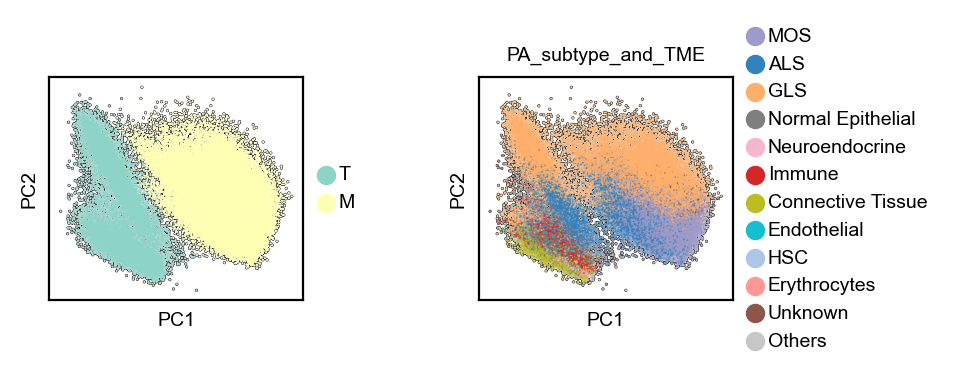

In [9]:
# PCA single panels - PA_subtype_and_TME
with rc_context({
    'figure.figsize': (1.45, 1.45),
    'font.family': 'Arial',  # Set font family to Arial
    'font.size': 7,  # Set font size to 12
    'axes.labelsize': 7,  # Axis label font size
    'xtick.labelsize': 7,  # X-axis tick font size
    'ytick.labelsize': 7   # Y-axis tick font size
    }):        
    sc.pl.embedding(integrated_set, basis="pca",color = ["Tumor or Model", "PA_subtype_and_TME"], 
                add_outline=True, frameon=True,
                vcenter=0, show=False, ncols=2, legend_fontsize=7, 
                legend_fontweight="normal", title="")
    for ax in plt.gcf().axes:
        if ax.get_title():  # Check if the title exists
            ax.title.set_fontsize(7)  # Set title font size to 7
#plt.suptitle(title, fontsize=20, y=1)
plt.show()

Whiten malignant cells and display only non-malignant populations in the TME.

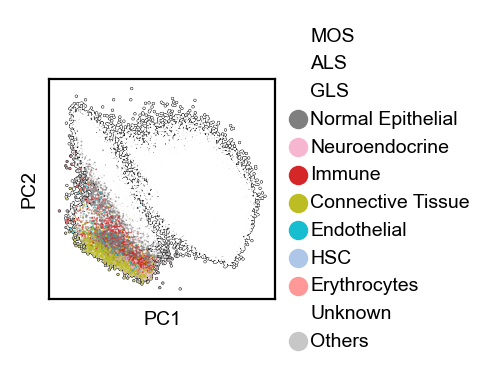

In [10]:
# PCA visualization on all samples withough batch correction (malignant cells are whitened)
integrated_set.uns["PA_subtype_and_TME_colors"] = [PDAC_colormap_simplified[key] for key in integrated_set.obs['PA_subtype_and_TME'].cat.categories]
with rc_context({
    'figure.figsize': (1.45, 1.45),
    'font.family': 'Arial',  # Set font family to Arial
    'font.size': 7,  # Set font size to 12
    'axes.labelsize': 7,  # Axis label font size
    'xtick.labelsize': 7,  # X-axis tick font size
    'ytick.labelsize': 7   # Y-axis tick font size
    }):        
    sc.pl.embedding(integrated_set, basis="pca",color = "PA_subtype_and_TME", 
                cmap="RdBu_r", add_outline=True, frameon=True,
                vcenter=0, show=False, ncols=1, legend_fontsize=7, 
                legend_fontweight="normal", title="")
    for ax in plt.gcf().axes:
        if ax.get_title():  # Check if the title exists
            ax.title.set_fontsize(7)  # Set title font size to 7
    plt.show()